In [174]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from matplotlib import rcParams
from scipy.interpolate import CubicSpline
rcParams.update({'figure.autolayout': True})
import os
import IPython

In [175]:
#The equation dy/dx = y^2 +1 
def q1_df(y,x=0):
    return y**2+1

### Euler's Method: $$y_{i+1} = y_i + \Delta x \times f(x_i,y_i)$$

In [176]:
# Euler's Method
# Input:
#   xi: initial value for x
#   yi: initial value for y
#   df: derivative function for f(y,x)
#   del_x: stepsize
#   steps: total steps
# Output:
#   result: 2d array of x and y values
def Euler(xi,yi,df,del_x,steps):
    step = steps+1
    x_array = np.zeros(step)
    y_array = np.zeros(step)
    for i in range(step):
        x_array[i] = xi
        y_array[i] = yi
        xi += del_x
        yi += del_x * df(yi,xi)
    result = np.stack((x_array,y_array))
    return result

### Runge Kutta 4: $$\begin{align} y_{i+1}&= y_i + \frac{h}{6} (k_1+2k_2+2k_3+k_4) \\ \text{where } k_1 &= f(y_i,x_i) \\ k_2 &= f(y_i+\frac{1}{2} h k_1,x_i+\frac{1}{2} h) \\k_3 &= f(y_i+\frac{1}{2} h k_2,x_i+\frac{1}{2} h) \\ k_4 &= f(y_i+ h k_3,x_i+h)\end{align}$$

In [177]:
# Runge-Kutta 4
# Input:
#   xi: initial value for x
#   yi: initial value for y
#   df: derivative function for f(y,x)
#   del_x: stepsize
#   steps: total steps
# Output:
#   result: 2d array of x and y values
def RK4(xi,yi,df,del_x,steps):
    step = steps+1
    x_array = np.zeros(step)
    y_array = np.zeros(step)
    h = del_x
    for i in range(step):
        x_array[i] = xi
        y_array[i] = yi
        k1 = df(yi,xi)
        k2 = df(yi+1/2*h*k1,xi+1/2*h)
        k3 = df(yi+1/2*h*k2,xi+1/2*h) 
        k4 = df(yi+h*k3,xi+h)
        xi += h
        yi += h/6*(k1+2*k2+2*k3+k4)
    result = np.stack((x_array,y_array))
    return result

In [178]:
steps = 100
x_range = [0,2*np.pi]
x_vals = np.linspace(x_range[0],x_range[1],1000)
y_vals = np.tan(x_vals)
del_x = x_range[1]/steps
E_vals = Euler(x_vals[0],y_vals[0],q1_df,del_x,steps)
RK4_vals = RK4(x_vals[0],y_vals[0],q1_df,del_x,steps)

/var/folders/sm/sjz00q7943zdql3vzxcjy5rw0000gn/T/ipykernel_30700/2878056858.py:3: RuntimeWarning: overflow encountered in scalar power
  return y**2+1


In [179]:
np.stack((E_vals[1][25:40],RK4_vals[1][25:40]))

array([[8.17292272e+000, 1.24327129e+001, 2.22076119e+001,
        5.32577329e+001, 2.31535960e+002, 3.59994537e+003,
        8.17876109e+005, 4.20303846e+010, 1.10995813e+020,
        7.74092859e+038, 3.76500876e+076, 8.90659799e+151,
        4.98429306e+302,             inf,             inf],
       [1.30674030e+002, 1.64048322e+012, 1.05132145e+173,
                    inf,             inf,             inf,
                    inf,             inf,             inf,
                    inf,             inf,             inf,
                    inf,             inf,             inf]])

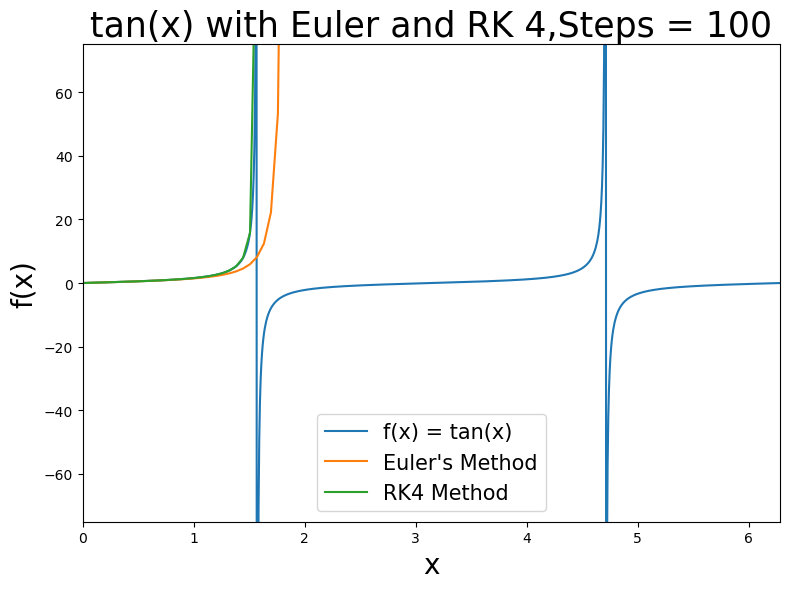

In [180]:
plt.rcParams["figure.figsize"] = (8,6)

plt.plot(x_vals,y_vals, label = "f(x) = tan(x)")
plt.plot(E_vals[0],E_vals[1], label = "Euler's Method")
plt.plot(RK4_vals[0],RK4_vals[1], label = "RK4 Method")

plt.xlabel("x",size= 20)
plt.ylabel("f(x)",size= 20)
plt.ylim(-75,75)
plt.xlim(0,2*np.pi)
plt.title("tan(x) with Euler and RK 4,Steps = %i"%steps,size= 25)
plt.legend(fontsize = 15);

### So the integration breaks at $\pi/2$. We will use x ~ 1.5 as the new limit.

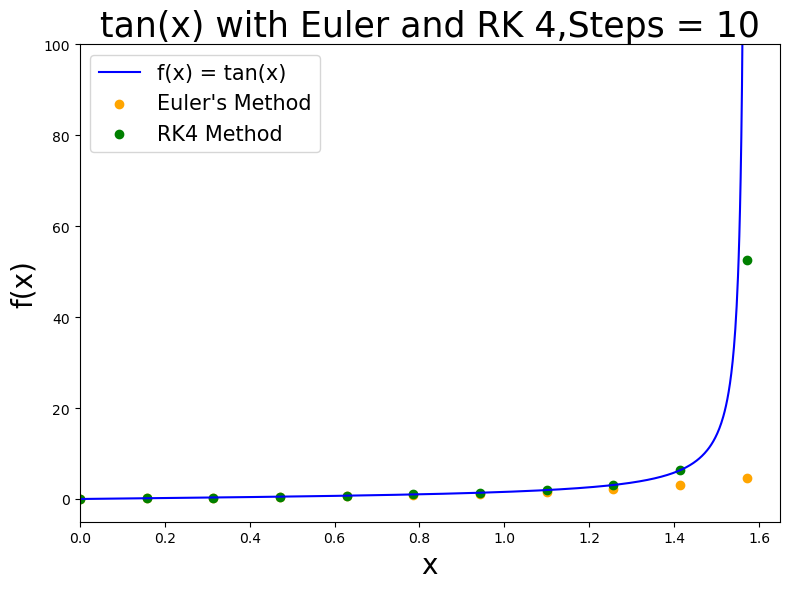

In [181]:
steps = 10
x_range = [0,1/2*np.pi]
x_vals = np.linspace(x_range[0],x_range[1],1000)
y_vals = np.tan(x_vals)
del_x = x_range[1]/steps
E_vals = Euler(x_vals[0],y_vals[0],q1_df,del_x,steps)
RK4_vals = RK4(x_vals[0],y_vals[0],q1_df,del_x,steps)
plt.rcParams["figure.figsize"] = (8,6)

plt.plot(x_vals,y_vals, c = "b",label = "f(x) = tan(x)")
plt.scatter(E_vals[0],E_vals[1], c = "orange",label = "Euler's Method")
plt.scatter(RK4_vals[0],RK4_vals[1], c = "green",label = "RK4 Method")

plt.xlabel("x",size= 20)
plt.ylabel("f(x)",size= 20)
plt.ylim(-5,100)
plt.xlim(0,1/2*np.pi*1.05)
plt.title("tan(x) with Euler and RK 4,Steps = %i"%steps,size= 25)
plt.legend(fontsize = 15);

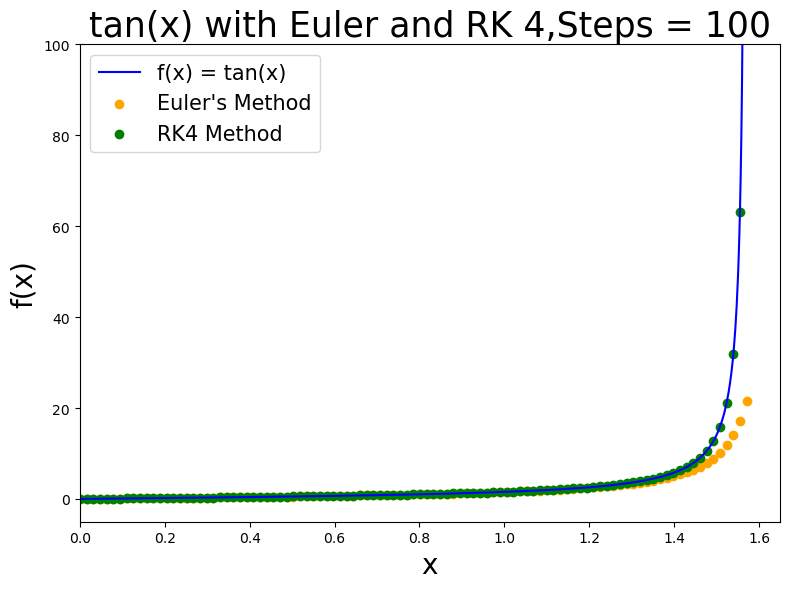

In [182]:
steps = 100
x_range = [0,1/2*np.pi]
x_vals = np.linspace(x_range[0],x_range[1],1000)
y_vals = np.tan(x_vals)
del_x = x_range[1]/steps
E_vals = Euler(x_vals[0],y_vals[0],q1_df,del_x,steps)
RK4_vals = RK4(x_vals[0],y_vals[0],q1_df,del_x,steps)
plt.rcParams["figure.figsize"] = (8,6)

plt.plot(x_vals,y_vals, c = "b",label = "f(x) = tan(x)")
plt.scatter(E_vals[0],E_vals[1], c = "orange",label = "Euler's Method")
plt.scatter(RK4_vals[0],RK4_vals[1], c = "green",label = "RK4 Method")

plt.xlabel("x",size= 20)
plt.ylabel("f(x)",size= 20)
plt.ylim(-5,100)
plt.xlim(0,1/2*np.pi*1.05)
plt.title("tan(x) with Euler and RK 4,Steps = %i"%steps,size= 25)
plt.legend(fontsize = 15);

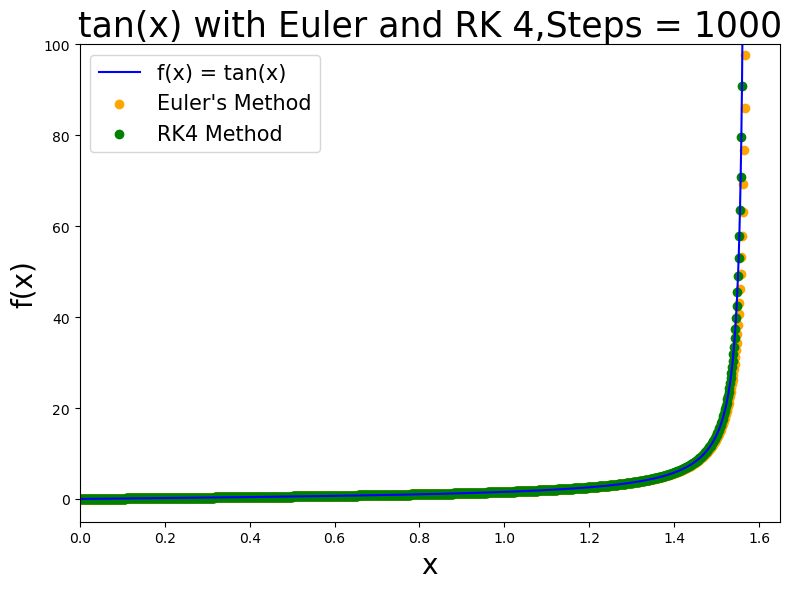

In [183]:
steps = int(1e3)
x_range = [0,1/2*np.pi]
x_vals = np.linspace(x_range[0],x_range[1],1000)
y_vals = np.tan(x_vals)
del_x = x_range[1]/steps
E_vals = Euler(x_vals[0],y_vals[0],q1_df,del_x,steps)
RK4_vals = RK4(x_vals[0],y_vals[0],q1_df,del_x,steps)
plt.rcParams["figure.figsize"] = (8,6)

plt.plot(x_vals,y_vals, c = "b",label = "f(x) = tan(x)")
plt.scatter(E_vals[0],E_vals[1], c = "orange",label = "Euler's Method")
plt.scatter(RK4_vals[0],RK4_vals[1], c = "green",label = "RK4 Method")

plt.xlabel("x",size= 20)
plt.ylabel("f(x)",size= 20)
plt.ylim(-5,100)
plt.xlim(0,1/2*np.pi*1.05)
plt.title("tan(x) with Euler and RK 4,Steps = %i"%steps,size= 25)
plt.legend(fontsize = 15);

In [ ]:
steps = int(1e7)
x_range = [0,1.5]
x_vals = np.linspace(x_range[0],x_range[1],1000)
y_vals = np.tan(x_vals)
del_x = x_range[1]/steps
E_vals = Euler(x_vals[0],y_vals[0],q1_df,del_x,steps)
RK4_vals = RK4(x_vals[0],y_vals[0],q1_df,del_x,steps)

In [ ]:
E_max_y = E_vals[1][-1]
RK_max_y = RK4_vals[1][-1]
act_max_y = np.tan(1.5)

print("Actual value: "+ str(act_max_y))
print("Integration value for Euler " + str(E_max_y) + ", fractional difference: " + str(np.abs((act_max_y-E_max_y)/E_max_y)))
print("Integration value for RK-4 " + str(RK_max_y)+ ", fractional difference: " + str(np.abs((act_max_y-RK_max_y)/RK_max_y)))


Actual value: 14.10141994717172
Integration value for Euler 14.101340543878246, fractional difference: 5.6309039007661505e-06
Integration value for RK-4 14.101419947168765, fractional difference: 2.0961419430356614e-13


In [ ]:
sample_s = 10
step_vals = np.logspace(1,6,sample_s,dtype = int)
RK_test_vals = np.zeros(sample_s)
E_test_vals = np.zeros(sample_s)
S_size_vals = np.zeros(sample_s)
n = 0
for i in (step_vals):
    del_x = x_range[1]/i
    Euler_temp = Euler(x_vals[0],y_vals[0],q1_df,del_x,i)
    RK_temp = RK4(x_vals[0],y_vals[0],q1_df,del_x,i)
    S_size_vals[n] = del_x
    E_test_vals[n] =  1.0-Euler_temp[1][-1]/E_max_y
    RK_test_vals[n]=  1.0-RK_temp[1][-1]/RK_max_y
    n+=1
conv_study = np.stack((S_size_vals,E_test_vals,RK_test_vals))
#conv_study = np.stack((step_vals,E_test_vals,RK_test_vals))

Euler's Slope: 0.8679579110198883
RK4's Slope: 3.8058392343662395


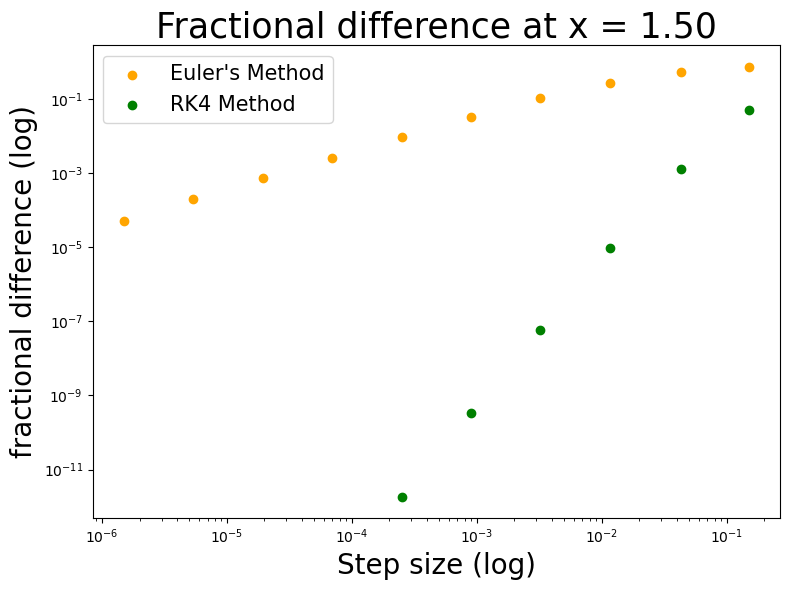

In [197]:
Euler_o = np.polyfit(np.log(conv_study[0]),np.log(conv_study[1]),1)

print("Euler's Slope: " + str(Euler_o[0]))
RK4_o= np.polyfit(np.log(conv_study[0][conv_study[2]>0]),np.log(conv_study[2][conv_study[2]>0]),1)
print("RK4's Slope: " + str(RK4_o[0]))


plt.rcParams["figure.figsize"] = (8,6)

plt.scatter(conv_study[0],conv_study[1], c = "orange",label = "Euler's Method")
plt.scatter(conv_study[0],conv_study[2], c = "green",label = "RK4 Method")

plt.xlabel("Step size (log)",size= 20)
plt.ylabel("fractional difference (log)",size= 20)
plt.yscale("log")
#plt.ylim(1e-30,1e1)
plt.xscale("log")
plt.title("Fractional difference at x = %.2f"%x_range[1],size= 25)
plt.legend(fontsize = 15);

In [203]:
conv_study[1][-1], conv_study[2][-1]

(np.float64(5.067403167757778e-05), np.float64(-3.823608096809039e-13))

In [213]:
m = 1.6737 *1e-27 #in kg
k = 1.3806*1e-23 #in J/k
T = 10000 #in k
sample = 100
v_range = np.linspace(0,50000,sample)
dv = v_range[-1]/sample

def MB_v(v, T = 10000):
    df = ((m)/(2*np.pi*k*T))**(3/2) * 4 * np.pi* v**2 * np.exp(-(m*v**2)/(2*k*T)) 
    return df

In [214]:
E_lyman = np.abs(13.6/4 - 13.6/1)*1.602 * 1e-19#in J
v_min = np.sqrt(2*E_lyman/m)
print("The minimum speed is " + str(v_min) + " m/s")
df = MB_v(v_range)
print("The total probability is: "+ str(np.sum(df)*dv))
v_min_p = np.sum(df[v_range<v_min])*dv
print("The probability at Vmin is: " + str(v_min_p))

The minimum speed is 44188.324184836485 m/s
The total probability is: 0.9899989891054581
The probability at Vmin is: 0.9899711707413166


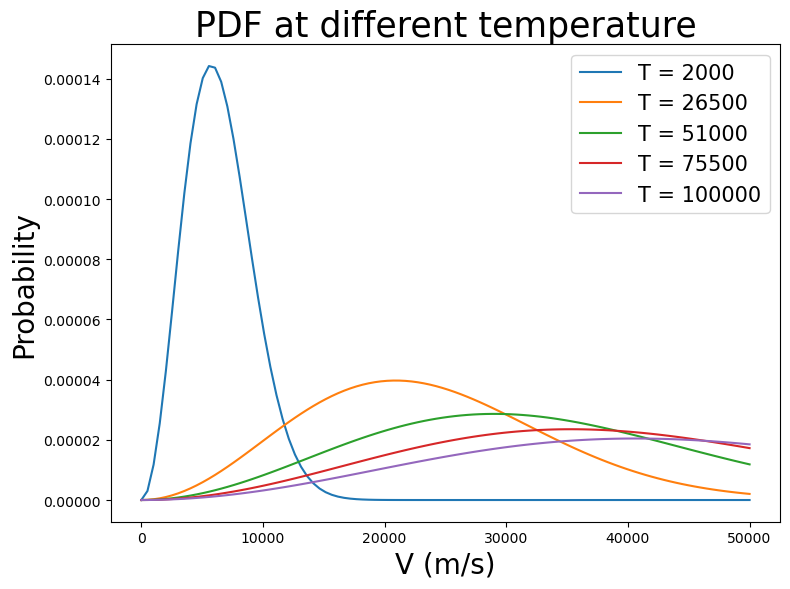

In [220]:
plt.rcParams["figure.figsize"] = (8,6)
T_range = np.linspace(2000, 100000,5)
for T in T_range:
    df = MB_v(v_range,T)
    plt.plot(v_range,df,label = "T = %i"%T)

plt.xlabel("V (m/s)",size= 20)
plt.ylabel("Probability",size= 20)
plt.title("PDF at different temperature",size= 25)
plt.legend(fontsize = 15);

In [ ]:
plt.rcParams["figure.figsize"] = (8,6)

plt.bar(v_range,df, width= dv,label = "PDF")
plt.vlines(v_min, 0, np.max(df),colors= "r", label = "Minimum excited speed")

plt.xlabel("V (m/s)",size= 20)
plt.ylabel("Probability",size= 20)
plt.title("PDF for Maxwell Boltzmann",size= 25)
plt.legend(fontsize = 15);

In [ ]:
v_max = 1e6
steps = 10
dv = v_min/steps
RK4(v_max,0,MB_v,dv,steps)  

array([[1000000.        , 1004418.83241848, 1008837.66483697,
        1013256.49725545, 1017675.32967393, 1022094.16209242,
        1026512.9945109 , 1030931.82692939, 1035350.65934787,
        1039769.49176635, 1044188.32418484],
       [      0.        ,       0.        ,       0.        ,
              0.        ,       0.        ,       0.        ,
              0.        ,       0.        ,       0.        ,
              0.        ,       0.        ]])